In [1]:
# Load Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [3]:
import json

with open("data/drug_master.json", "r") as f:
    drug_master = json.load(f)

In [4]:
type(drug_master)

dict

In [5]:
if isinstance(drug_master, dict):
    print(drug_master.keys())
else:
    print("Number of entries:", len(drug_master))
    print(drug_master[0])

dict_keys(['be-2254', 'tasimelteon', 'esaxerenone', 'ixazomib-citrate', 'alendronate', 'dazmegrel', 'nobiletin', 'azd7986', 'bebt-908', 'nitromide', 'saroglitazar', 'l-368899', 'betamethasone-valerate', '2-methylimidazole', 'pnu-282987', 'kx2-391', 'asivatrep', 'diclofenac', 'emeramide', 'hemado', 'proadifen', 'simvastatin', 'gabexate', 'cis-aconitic-acid', 'thioperamide', 'methicillin', 'capadenoson', 'fluvoxamine', 'cp-316819', 'bay-11-7085', 'capsazepine', 'montelukast', 'cgp-52411', 'sym-2206', 'pac-1', 'tenofovir-disoproxil', 'relebactam', 'cerulenin', 'gr-135531', 'pipotiazine-palmitate', 'erlotinib', 'farnesyl-thiosalicylic-acid-amide', 'losmapimod', 'ru-42173', '(r)-baclofen', 'raloxifene', 'butaprost', 'aee788', 'thiamet-g', 'mek1-2-inhibitor', 'abamectin', 'gsk356278', 'salinomycin', 'riodoxol', 'umeclidinium', 'a922500', 'dextran', 'pf-4191834', 'ursodeoxycholyltaurine', 'ethynodiol-diacetate', 'oxyclozanide', 'terreic-acid-(-)', 'cb-5083', 'pindolol-(-)', 'ambrisentan', 'se

In [6]:
first_drug_name = next(iter(drug_master))

print("First drug name:", first_drug_name)
print(drug_master[first_drug_name])

First drug name: be-2254
{'name': 'be-2254', 'pubchem_cid': '86308637', 'inchi_key': 'PZZOEXPDTYIBPI-MRXNPFEDSA-N', 'smiles': 'Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|', 'broad_id': 'BRD-A24429032-003-03-2', 'moa': 'adrenergic receptor antagonist', 'target': 'ADRA1A', 'clinical_phase': 'Phase 2', 'disease_area': '', 'indication': '', 'fda_approved': False}


In [7]:
records = []

for drug_name, info in drug_master.items():
    records.append({
        "drug_name": drug_name,
        "pubchem_cid": info.get("pubchem_cid"),
        "smiles": info.get("smiles"),
        "moa": info.get("moa"),
        "target": info.get("target"),
        "fda_approved": info.get("fda_approved")
    })

df = pd.DataFrame(records)

print(df.shape)
df.head()

(6801, 6)


,drug_name,pubchem_cid,smiles,moa,target,fda_approved
0,be-2254,86308637,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,adrenergic receptor antagonist,ADRA1A,False
1,tasimelteon,10220503,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,melatonin receptor agonist,MTNR1A|MTNR1B,True
2,esaxerenone,25052023,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,mineralocorticoid receptor antagonist,,False
3,ixazomib-citrate,69040311,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,proteasome inhibitor,,True
4,alendronate,44400013,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,True


In [8]:
print("Missing SMILES:", df["smiles"].isna().sum())
print("Total compounds:", len(df))

Missing SMILES: 0
Total compounds: 6801


In [9]:
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)

print("Invalid RDKit molecules:", df["mol"].isna().sum())

Invalid RDKit molecules: 22


In [10]:
df = df[df["mol"].notna()].copy()

print("Remaining valid compounds:", len(df))

Remaining valid compounds: 6779


In [11]:
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

def mol_to_morgan_array(mol, n_bits=2048):
    fp = morgan_generator.GetFingerprint(mol)

    arr = np.zeros((n_bits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)

    return arr

In [12]:
X = np.vstack(
    df["mol"].apply(mol_to_morgan_array).values
)

print("Morgan fingerprint matrix shape:", X.shape)
print("Unique values:", np.unique(X))
print("Average active bits per compound:", X.sum(axis=1).mean())

Morgan fingerprint matrix shape: (6779, 2048)
Unique values: [0. 1.]
Average active bits per compound: 44.54241


In [13]:
X_train, X_temp = train_test_split(
    X,
    test_size=0.30,
    random_state=42
)

X_val, X_test = train_test_split(
    X_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4745, 2048)
Validation: (1017, 2048)
Test: (1017, 2048)


In [14]:
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32)
)

val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32)
)

test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [15]:
class MorganAutoencoder(nn.Module):
    def __init__(self, input_dim=2048, latent_dim=15):
        super().__init__()

        # Compress 2048 Morgan bits down to 15 learned numbers
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),

            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, latent_dim)
        )

        # Expand those 15 numbers back into 2048 Morgan-bit probabilities
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 512),
            nn.ReLU(),

            nn.Linear(512, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent_vector = self.encoder(x)
        reconstruction = self.decoder(latent_vector)

        return reconstruction, latent_vector

In [16]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = MorganAutoencoder(
    input_dim=X.shape[1],
    latent_dim=15
).to(device)

criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Using device:", device)
print(model)

Using device: cpu
MorganAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=15, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=2048, bias=True)
    (5): Sigmoid()
  )
)


In [ ]:
num_epochs = 50

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    total_train_loss = 0

    for (batch,) in train_loader:
        batch = batch.to(device)

        reconstruction, _ = model(batch)
        loss = criterion(reconstruction, batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * batch.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # Validation phase
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for (batch,) in val_loader:
            batch = batch.to(device)

            reconstruction, _ = model(batch)
            loss = criterion(reconstruction, batch)

            total_val_loss += loss.item() * batch.size(0)

    avg_val_loss = total_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train: {avg_train_loss:.4f} | "
        f"Val: {avg_val_loss:.4f}"
    )

In [ ]:
import os
os.makedirs("models", exist_ok=True)

In [ ]:
# Reinitialize a fresh model before retraining
model = MorganAutoencoder(
    input_dim=X.shape[1],
    latent_dim=15
).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100
patience = 5

best_val_loss = float("inf")
epochs_without_improvement = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0

    for (batch,) in train_loader:
        batch = batch.to(device)

        reconstruction, _ = model(batch)
        loss = criterion(reconstruction, batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * batch.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for (batch,) in val_loader:
            batch = batch.to(device)

            reconstruction, _ = model(batch)
            loss = criterion(reconstruction, batch)

            total_val_loss += loss.item() * batch.size(0)

    avg_val_loss = total_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch + 1:02d} | "
        f"Train: {avg_train_loss:.4f} | "
        f"Val: {avg_val_loss:.4f}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0

        torch.save(
            model.state_dict(),
            "models/morgan_autoencoder_best.pt"
        )
    else:
        epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

In [ ]:
model.load_state_dict(
    torch.load("models/morgan_autoencoder_best.pt", map_location=device)
)

model.eval()

print("Best model loaded.")

In [ ]:
X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
).to(device)

with torch.no_grad():
    X_test_reconstructed, Z_test = model(X_test_tensor)

X_test_reconstructed = X_test_reconstructed.cpu().numpy()
Z_test = Z_test.cpu().numpy()

print("Reconstructed test matrix:", X_test_reconstructed.shape)
print("Test latent matrix:", Z_test.shape)

In [ ]:
X_test_predicted_bits = (X_test_reconstructed >= 0.5).astype(int)

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score

# Raw bitwise accuracy
bitwise_accuracy = (X_test_predicted_bits == X_test).mean()

# Per-compound F1 score
f1_scores = [
    f1_score(true_bits, pred_bits, zero_division=0)
    for true_bits, pred_bits in zip(X_test, X_test_predicted_bits)
]

# Per-compound ROC-AUC using the model's probabilities
auc_scores = [
    roc_auc_score(true_bits, predicted_probs)
    for true_bits, predicted_probs in zip(X_test, X_test_reconstructed)
    if len(np.unique(true_bits)) > 1
]

print("Bitwise accuracy:", round(bitwise_accuracy, 4))
print("Mean F1:", round(np.mean(f1_scores), 4))
print("Median F1:", round(np.median(f1_scores), 4))
print("Mean ROC-AUC:", round(np.mean(auc_scores), 4))
print("Median ROC-AUC:", round(np.median(auc_scores), 4))

In [ ]:
# Run every valid compound through the trained encoder
X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

model.eval()

with torch.no_grad():
    _, Z_all = model(X_tensor)

Z_all = Z_all.cpu().numpy()

print("Latent matrix shape:", Z_all.shape)

In [ ]:
latent_df = pd.DataFrame(
    Z_all,
    columns=[f"latent_{i+1}" for i in range(Z_all.shape[1])]
)

latent_output = pd.concat(
    [
        df.drop(columns=["mol"]).reset_index(drop=True),
        latent_df
    ],
    axis=1
)

latent_output.to_csv(
    "data/morgan_autoencoder_latent15.csv",
    index=False
)

latent_output.head()

In [ ]:
import umap.umap_ as umap

In [ ]:
%pip install umap-learn

In [ ]:
# Recreate the model object
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MorganAutoencoder(
    input_dim=X.shape[1],
    latent_dim=15
).to(device)

model.load_state_dict(
    torch.load("models/morgan_autoencoder_best.pt", map_location=device)
)

model.eval()

In [ ]:
X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

with torch.no_grad():
    _, Z_all = model(X_tensor)

Z_all = Z_all.cpu().numpy()

print("Latent matrix shape:", Z_all.shape)

In [ ]:
latent_umap = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

Z_umap = latent_umap.fit_transform(Z_all)

print(Z_umap.shape)

In [ ]:
latent_output["umap_1"] = Z_umap[:, 0]
latent_output["umap_2"] = Z_umap[:, 1]

latent_output.to_csv(
    "data/morgan_autoencoder_latent15_umap.csv",
    index=False
)

latent_output[["drug_name", "moa", "umap_1", "umap_2"]].head()

In [ ]:
plt.figure(figsize=(9, 7))

plt.scatter(
    latent_output["umap_1"],
    latent_output["umap_2"],
    s=4,
    alpha=0.5
)

plt.xlabel("UMAP 1", fontsize=16)
plt.ylabel("UMAP 2", fontsize=16)
plt.title("UMAP of 15D Morgan Autoencoder Latent Space", fontsize=18)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.tight_layout()
plt.show()

In [ ]:
bottleneck_sizes = [2, 5, 10, 15, 25, 50, 100]

bottleneck_sizes

In [17]:
# New Bottlenecks 

In [18]:
import os
import pandas as pd

def run_bottleneck_experiment(latent_dim):
    
    # Fresh model for this bottleneck size
    model = MorganAutoencoder(
        input_dim=X.shape[1],
        latent_dim=latent_dim
    ).to(device)

    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    num_epochs = 100
    patience = 5

    best_val_loss = float("inf")
    epochs_without_improvement = 0

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):

        # Training
        model.train()
        total_train_loss = 0

        for (batch,) in train_loader:
            batch = batch.to(device)

            reconstruction, _ = model(batch)
            loss = criterion(reconstruction, batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * batch.size(0)

        avg_train_loss = total_train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(device)

                reconstruction, _ = model(batch)
                loss = criterion(reconstruction, batch)

                total_val_loss += loss.item() * batch.size(0)

        avg_val_loss = total_val_loss / len(val_loader.dataset)
        val_losses.append(avg_val_loss)

        print(
            f"Latent {latent_dim} | "
            f"Epoch {epoch + 1:03d} | "
            f"Train: {avg_train_loss:.4f} | "
            f"Val: {avg_val_loss:.4f}"
        )

        # Early stopping + separate checkpoint per bottleneck size
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0

            torch.save(
                model.state_dict(),
                f"models/morgan_autoencoder_latent{latent_dim}_best.pt"
            )

        else:
            epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch + 1}")
                break

    # Reload the best checkpoint before testing
    model.load_state_dict(
        torch.load(
            f"models/morgan_autoencoder_latent{latent_dim}_best.pt",
            map_location=device
        )
    )

    return model, best_val_loss, train_losses, val_losses, epoch + 1

In [19]:
# Quick test: run only one new bottleneck size first
test_model, test_best_val_loss, test_train_losses, test_val_losses, test_epochs = (
    run_bottleneck_experiment(latent_dim=5)
)

print("Best validation loss:", test_best_val_loss)
print("Epochs trained:", test_epochs)

Latent 5 | Epoch 001 | Train: 0.1752 | Val: 0.0825
Latent 5 | Epoch 002 | Train: 0.0812 | Val: 0.0793
Latent 5 | Epoch 003 | Train: 0.0791 | Val: 0.0768
Latent 5 | Epoch 004 | Train: 0.0761 | Val: 0.0740
Latent 5 | Epoch 005 | Train: 0.0729 | Val: 0.0714
Latent 5 | Epoch 006 | Train: 0.0701 | Val: 0.0698
Latent 5 | Epoch 007 | Train: 0.0680 | Val: 0.0685
Latent 5 | Epoch 008 | Train: 0.0661 | Val: 0.0676
Latent 5 | Epoch 009 | Train: 0.0646 | Val: 0.0670
Latent 5 | Epoch 010 | Train: 0.0633 | Val: 0.0665
Latent 5 | Epoch 011 | Train: 0.0621 | Val: 0.0662
Latent 5 | Epoch 012 | Train: 0.0611 | Val: 0.0660
Latent 5 | Epoch 013 | Train: 0.0601 | Val: 0.0659
Latent 5 | Epoch 014 | Train: 0.0592 | Val: 0.0659
Latent 5 | Epoch 015 | Train: 0.0584 | Val: 0.0658
Latent 5 | Epoch 016 | Train: 0.0574 | Val: 0.0660
Latent 5 | Epoch 017 | Train: 0.0566 | Val: 0.0659
Latent 5 | Epoch 018 | Train: 0.0559 | Val: 0.0660
Latent 5 | Epoch 019 | Train: 0.0552 | Val: 0.0664
Latent 5 | Epoch 020 | Train: 0

In [20]:
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np

def evaluate_autoencoder(model, data_loader):
    model.eval()

    all_true = []
    all_prob = []

    with torch.no_grad():
        for (batch,) in data_loader:
            batch = batch.to(device)

            reconstruction, _ = model(batch)

            all_true.append(batch.cpu().numpy())
            all_prob.append(reconstruction.cpu().numpy())

    y_true = np.concatenate(all_true, axis=0)
    y_prob = np.concatenate(all_prob, axis=0)
    y_pred = (y_prob >= 0.5).astype(int)

    bitwise_accuracy = (y_pred == y_true).mean()

    auc_scores = []
    f1_scores = []

    for bit in range(y_true.shape[1]):
        if len(np.unique(y_true[:, bit])) < 2:
            continue

        auc_scores.append(roc_auc_score(y_true[:, bit], y_prob[:, bit]))
        f1_scores.append(
            f1_score(y_true[:, bit], y_pred[:, bit], zero_division=0)
        )

    return {
        "bitwise_accuracy": bitwise_accuracy,
        "mean_roc_auc": np.mean(auc_scores),
        "mean_f1": np.mean(f1_scores)
    }

metrics_5 = evaluate_autoencoder(test_model, test_loader)
metrics_5

{'bitwise_accuracy': np.float64(0.9835271094518191),
 'mean_roc_auc': np.float64(0.765603463334393),
 'mean_f1': np.float64(0.11561204924466364)}

In [21]:
results = [
    {
        "latent_dim": 5,
        "best_val_loss": test_best_val_loss,
        "epochs_trained": test_epochs,
        **metrics_5
    }
]

for latent_dim in [2, 10, 15, 25, 50, 100]:
    
    print("\n" + "=" * 60)
    print(f"Running bottleneck size: {latent_dim}")
    print("=" * 60)

    model, best_val_loss, train_losses, val_losses, epochs_trained = (
        run_bottleneck_experiment(latent_dim=latent_dim)
    )

    metrics = evaluate_autoencoder(model, test_loader)

    results.append(
        {
            "latent_dim": latent_dim,
            "best_val_loss": best_val_loss,
            "epochs_trained": epochs_trained,
            **metrics
        }
    )

results_df = pd.DataFrame(results).sort_values("latent_dim")

results_df.to_csv(
    "data/morgan_autoencoder_bottleneck_sweep_results.csv",
    index=False
)

results_df


Running bottleneck size: 2
Latent 2 | Epoch 001 | Train: 0.1599 | Val: 0.0826
Latent 2 | Epoch 002 | Train: 0.0814 | Val: 0.0797
Latent 2 | Epoch 003 | Train: 0.0795 | Val: 0.0774
Latent 2 | Epoch 004 | Train: 0.0767 | Val: 0.0753
Latent 2 | Epoch 005 | Train: 0.0748 | Val: 0.0741
Latent 2 | Epoch 006 | Train: 0.0736 | Val: 0.0735
Latent 2 | Epoch 007 | Train: 0.0728 | Val: 0.0730
Latent 2 | Epoch 008 | Train: 0.0721 | Val: 0.0728
Latent 2 | Epoch 009 | Train: 0.0716 | Val: 0.0725
Latent 2 | Epoch 010 | Train: 0.0711 | Val: 0.0724
Latent 2 | Epoch 011 | Train: 0.0707 | Val: 0.0722
Latent 2 | Epoch 012 | Train: 0.0703 | Val: 0.0721
Latent 2 | Epoch 013 | Train: 0.0699 | Val: 0.0720
Latent 2 | Epoch 014 | Train: 0.0696 | Val: 0.0720
Latent 2 | Epoch 015 | Train: 0.0693 | Val: 0.0718
Latent 2 | Epoch 016 | Train: 0.0690 | Val: 0.0719
Latent 2 | Epoch 017 | Train: 0.0687 | Val: 0.0718
Latent 2 | Epoch 018 | Train: 0.0685 | Val: 0.0719
Latent 2 | Epoch 019 | Train: 0.0682 | Val: 0.0719
Lat

,latent_dim,best_val_loss,epochs_trained,bitwise_accuracy,mean_roc_auc,mean_f1
1,2,0.071797,20,0.981765,0.701894,0.050037
0,5,0.065805,20,0.983527,0.765603,0.115612
2,10,0.062165,23,0.984492,0.791783,0.155421
3,15,0.060906,25,0.984963,0.802896,0.183772
4,25,0.059683,24,0.985392,0.807581,0.198293
5,50,0.060774,27,0.985007,0.805302,0.176842
6,100,0.061680,29,0.985031,0.800595,0.191983


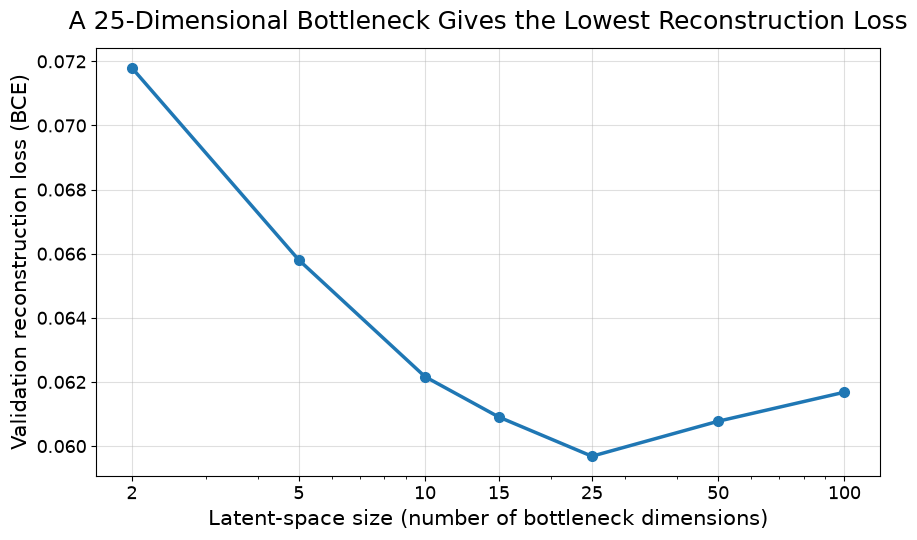

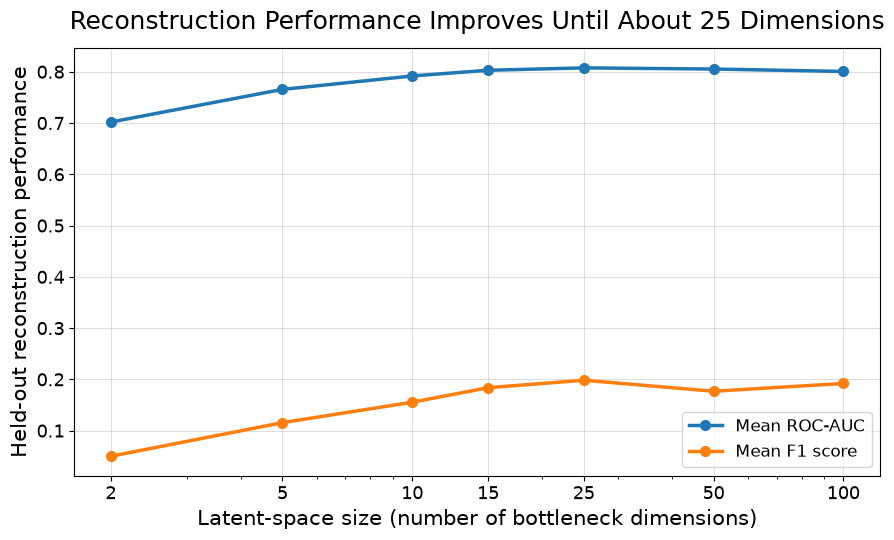

In [25]:
import os
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

# Bigger default text
TITLE_SIZE = 18
LABEL_SIZE = 15
TICK_SIZE = 13
LEGEND_SIZE = 12

# Plot 1: validation reconstruction loss
plt.figure(figsize=(9, 5.5))

plt.plot(
    results_df["latent_dim"],
    results_df["best_val_loss"],
    marker="o",
    linewidth=2.5,
    markersize=7
)

plt.xscale("log")
plt.xlabel("Latent-space size (number of bottleneck dimensions)", fontsize=LABEL_SIZE)
plt.ylabel("Validation reconstruction loss (BCE)", fontsize=LABEL_SIZE)
plt.title(
    "A 25-Dimensional Bottleneck Gives the Lowest Reconstruction Loss",
    fontsize=TITLE_SIZE,
    pad=14
)

plt.xticks(results_df["latent_dim"], results_df["latent_dim"], fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.grid(True, alpha=0.4)
plt.tight_layout()

plt.savefig(
    "figures/bottleneck_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Plot 2: held-out reconstruction metrics
plt.figure(figsize=(9, 5.5))

plt.plot(
    results_df["latent_dim"],
    results_df["mean_roc_auc"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Mean ROC-AUC"
)

plt.plot(
    results_df["latent_dim"],
    results_df["mean_f1"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Mean F1 score"
)

plt.xscale("log")
plt.xlabel("Latent-space size (number of bottleneck dimensions)", fontsize=LABEL_SIZE)
plt.ylabel("Held-out reconstruction performance", fontsize=LABEL_SIZE)
plt.title(
    "Reconstruction Performance Improves Until About 25 Dimensions",
    fontsize=TITLE_SIZE,
    pad=14
)

plt.xticks(results_df["latent_dim"], results_df["latent_dim"], fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.legend(fontsize=LEGEND_SIZE, loc="lower right")
plt.grid(True, alpha=0.4)
plt.tight_layout()

plt.savefig(
    "figures/bottleneck_test_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

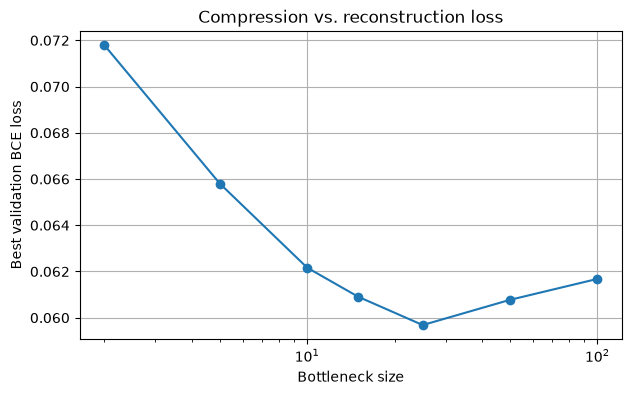

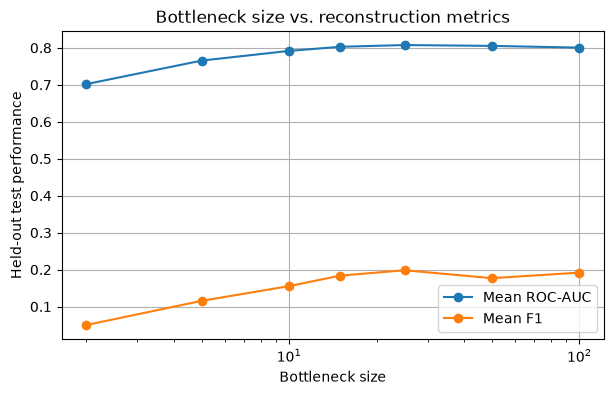

In [23]:
plt.figure(figsize=(7, 4))
plt.plot(results_df["latent_dim"], results_df["best_val_loss"], marker="o")
plt.xscale("log")
plt.xlabel("Bottleneck size")
plt.ylabel("Best validation BCE loss")
plt.title("Compression vs. reconstruction loss")
plt.grid(True)
plt.savefig("figures/bottleneck_validation_loss.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(results_df["latent_dim"], results_df["mean_roc_auc"], marker="o", label="Mean ROC-AUC")
plt.plot(results_df["latent_dim"], results_df["mean_f1"], marker="o", label="Mean F1")
plt.xscale("log")
plt.xlabel("Bottleneck size")
plt.ylabel("Held-out test performance")
plt.title("Bottleneck size vs. reconstruction metrics")
plt.legend()
plt.grid(True)
plt.savefig("figures/bottleneck_test_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
import os
os.makedirs("figures", exist_ok=True)